In [4]:
#PROJECT TEAM ID:PTID-CDS-MAR-26-11138
#PROJECT ID:PRCP-1020-HousePricePred

In [5]:
## INTRODUCTION:

#This project focuses on predicting house prices using Machine Learning techniques. 
#The dataset contains various house features such as location, living area, overall quality, garage size, and basement area.
#Exploratory Data Analysis (EDA) and multiple regression models are used to analyze the data and predict house prices accurately. 
#The project also identifies the key factors affecting house prices and provides useful customer insights.

In [6]:
## Objective:

#* Perform Exploratory Data Analysis (EDA) on housing data
#* Handle missing values and preprocess the dataset
#* Build machine learning models to predict house prices
#* Compare model performance and select the best model
#* Identify important factors affecting house prices
#* Provide customer suggestions based on the analysis

In [7]:
#Import Required Libraries

In [8]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Display settings
pd.set_option('display.max_columns', None)

In [9]:
#Load Dataset

In [10]:
# Load Dataset
df = pd.read_csv(r"C:\Users\HP\Downloads\data.csv")

# Display first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
#Understanding the Dataset

In [12]:
# Shape of dataset
df.shape

(1460, 81)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [14]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [15]:
#Missing Value Analysis

In [16]:
# Missing Values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

missing_values.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [17]:
#Visualizing Missing Values

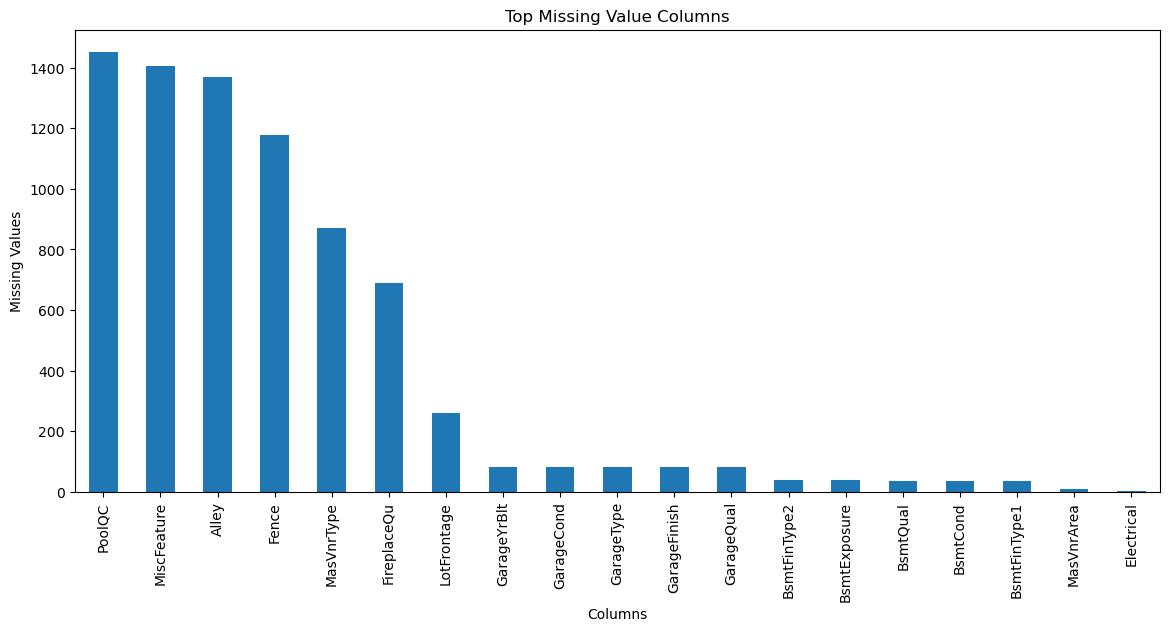

In [18]:
plt.figure(figsize=(14,6))
missing_values.head(20).plot(kind='bar')
plt.title('Top Missing Value Columns')
plt.xlabel('Columns')
plt.ylabel('Missing Values')
plt.xticks(rotation=90)
plt.show()

In [19]:
### Graph Insight:
#Columns with extremely high missing values may not contribute significantly.
#Some features can be dropped to improve model efficiency.

In [20]:
#Data Cleaning

In [22]:
# Drop columns with more than 40% missing values
threshold = len(df) * 0.4
df = df.dropna(thresh=threshold, axis=1)

df.shape

(1460, 77)

In [23]:
### Insight:
#Removing highly incomplete columns reduces noise.
#Helps improve model performance.

In [24]:
#Separate Numerical and Categorical Columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [25]:
#Handle Missing Numerical Values

In [26]:
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [27]:
### Insight:
#Median imputation handles skewed numerical data better than mean.
#Prevents outlier influence.

In [28]:
#Handle Missing Categorical Values

In [29]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [30]:
### Insights:
#Most frequent strategy preserves category distribution.

In [31]:
#Exploratory Data Analysis (EDA)

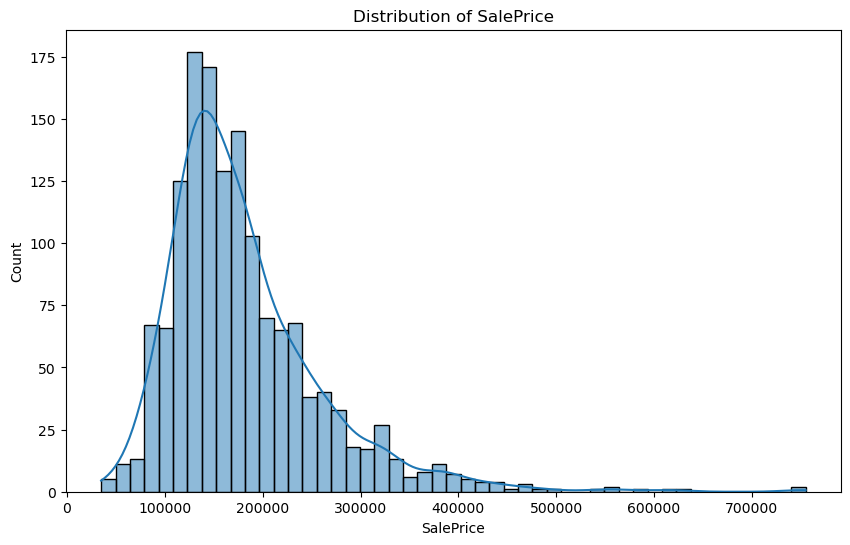

In [33]:
#Target Variable Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

In [34]:
### Graph Insights:
#SalePrice is positively skewed.
#Most houses fall in mid-price ranges.
#Very expensive houses act as outliers.

In [35]:
#Correlation Heatmap

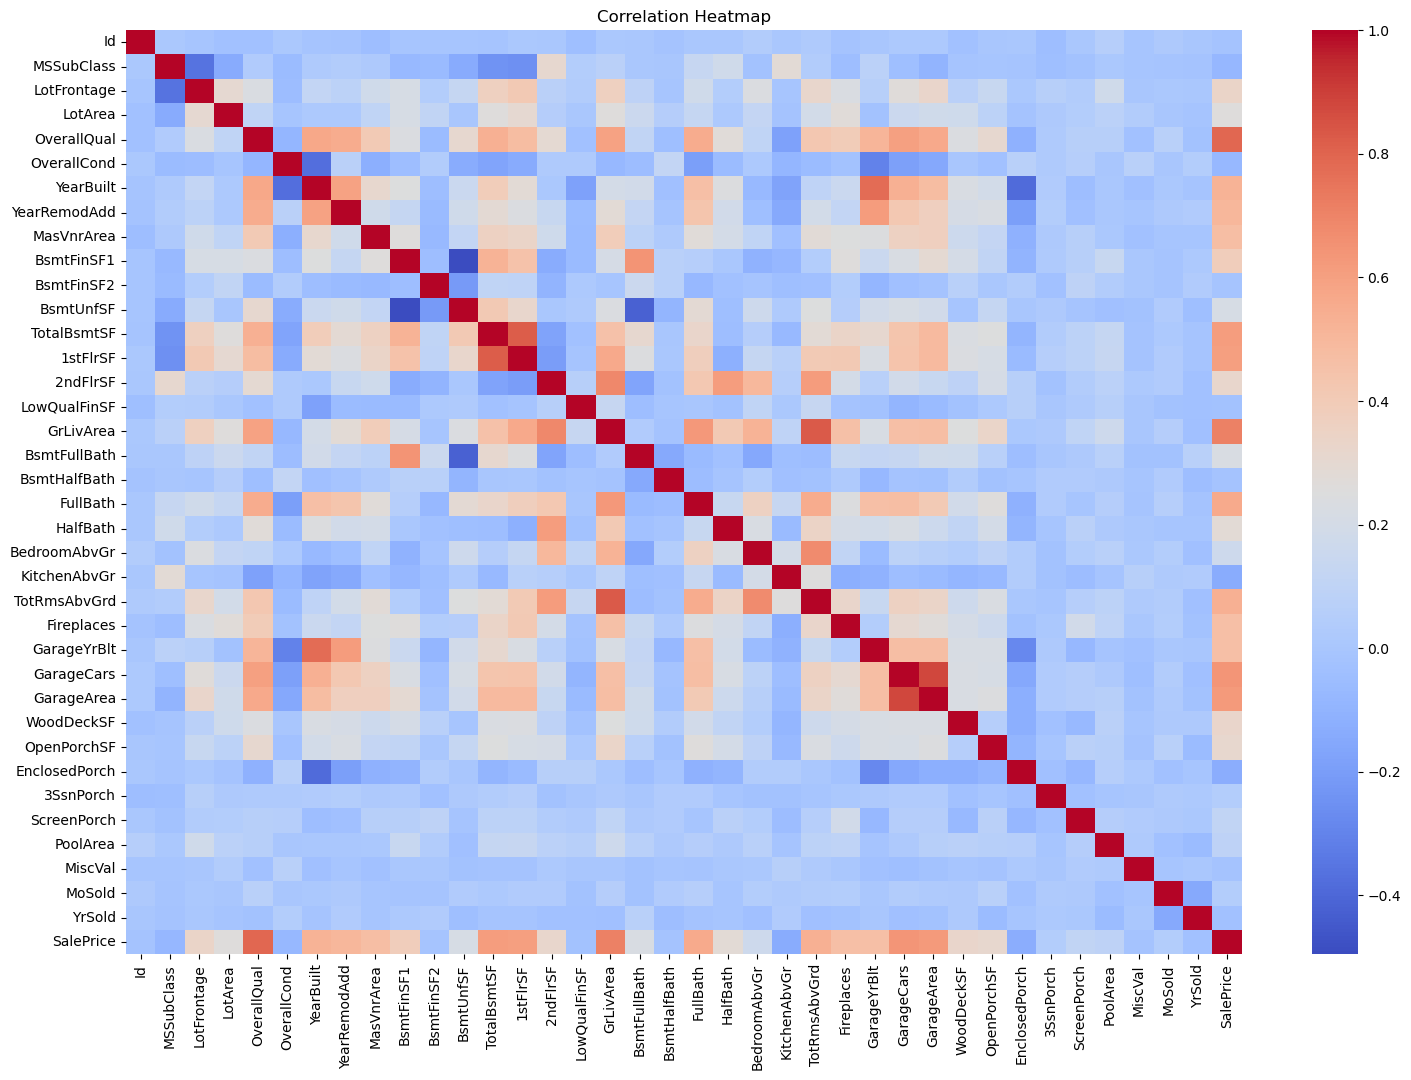

In [38]:
plt.figure(figsize=(18,12))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [39]:
### Graph Insights:

#Features like OverallQual, GrLivArea, GarageCars, and TotalBsmtSF show strong positive correlation with SalePrice.
#Strong correlations indicate highly influential features.

In [40]:
#Top Correlated Features with SalePrice
corr_target = correlation['SalePrice'].sort_values(ascending=False)

corr_target.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

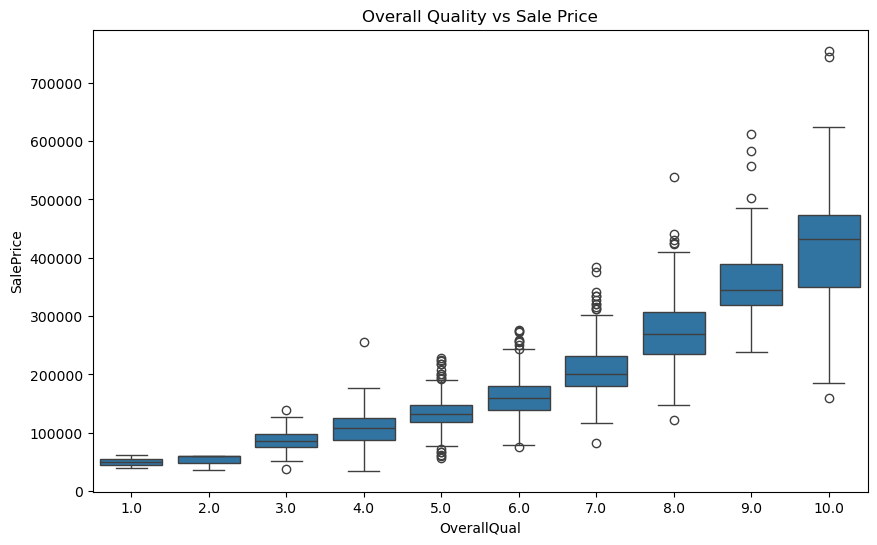

In [43]:
#SalePrice vs Overall Quality
plt.figure(figsize=(10,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Overall Quality vs Sale Price')
plt.show()

In [44]:
### Graph Insights:

#Higher construction quality leads to significantly higher house prices.
#Quality is one of the strongest predictors.

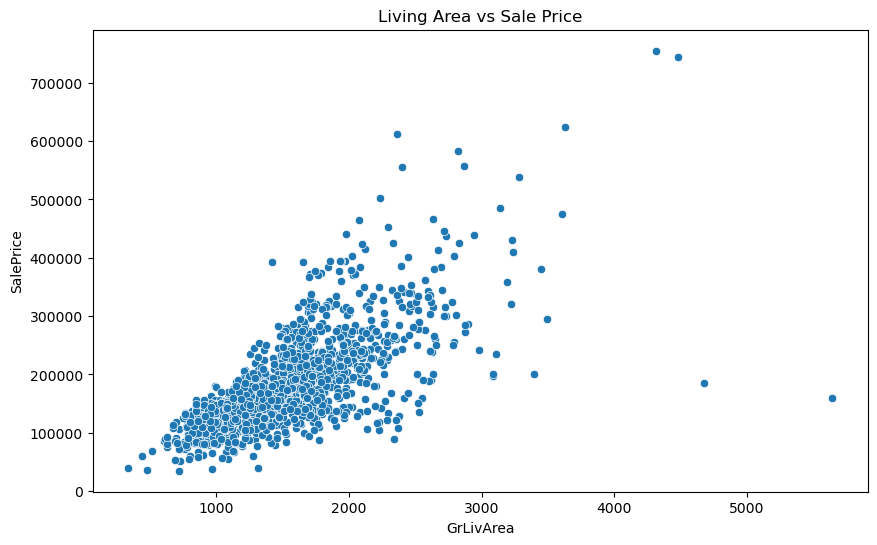

In [47]:
#SalePrice vs Living Area
plt.figure(figsize=(10,6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Living Area vs Sale Price')
plt.show()

In [48]:
### Graph Insights:

#Larger homes generally have higher sale prices.
#Some outliers exist with very large areas but moderate prices.

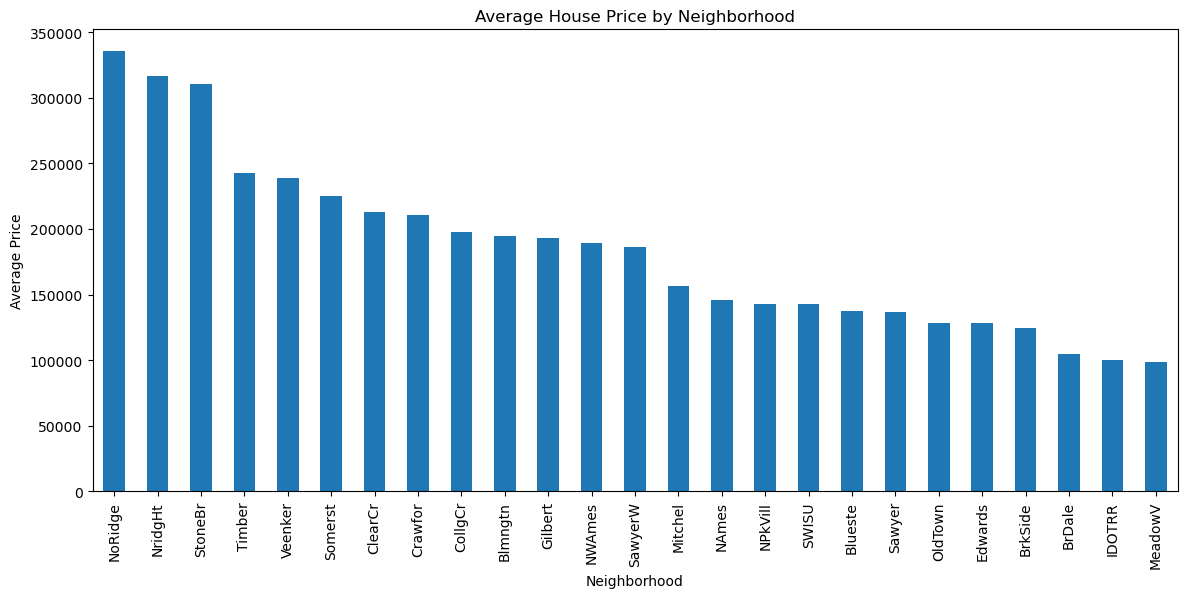

In [50]:
#Neighborhood Analysis
plt.figure(figsize=(14,6))
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

neighborhood_price.plot(kind='bar')
plt.title('Average House Price by Neighborhood')
plt.ylabel('Average Price')
plt.show()

In [51]:
### Graph Insights:

#House prices vary greatly across neighborhoods.
#Premium neighborhoods command significantly higher prices.

In [52]:
### Feature Engineering
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

In [53]:
### Insights:

#Machine learning models require numerical inputs.
#Label Encoding converts text categories into numeric form.

In [54]:
#Define Features and Target

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [55]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [56]:
### Insights:

#80% data used for training.
#20% data reserved for testing.

In [60]:
#Model Building
#Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [61]:
#Model 2: Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [62]:
#Model 3: XGBoost Regressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [63]:
#Model Evaluation Function
# Evaluation Function

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance")
    print('-'*40)
    print('MAE :', mae)
    print('MSE :', mse)
    print('RMSE:', rmse)
    print('R2 Score:', r2)

    return [model_name, mae, rmse, r2]

In [64]:
#Evaluate All Models
results = []

results.append(evaluate_model(y_test, lr_pred, 'Linear Regression'))
results.append(evaluate_model(y_test, rf_pred, 'Random Forest'))
results.append(evaluate_model(y_test, xgb_pred, 'XGBoost'))


Linear Regression Performance
----------------------------------------
MAE : 21494.768334528264
MSE : 1178561697.9870715
RMSE: 34330.18639604323
R2 Score: 0.8463479040979047

Random Forest Performance
----------------------------------------
MAE : 17520.620804794522
MSE : 810790873.6855913
RMSE: 28474.38978600931
R2 Score: 0.8942951249027874

XGBoost Performance
----------------------------------------
MAE : 16044.049242829624
MSE : 631502057.4861361
RMSE: 25129.704683623644
R2 Score: 0.9176694653619274


In [65]:
#Model Comparison Report
comparison = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2 Score'])

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,21494.768335,34330.186396,0.846348
1,Random Forest,17520.620805,28474.389786,0.894295
2,XGBoost,16044.049243,25129.704684,0.917669


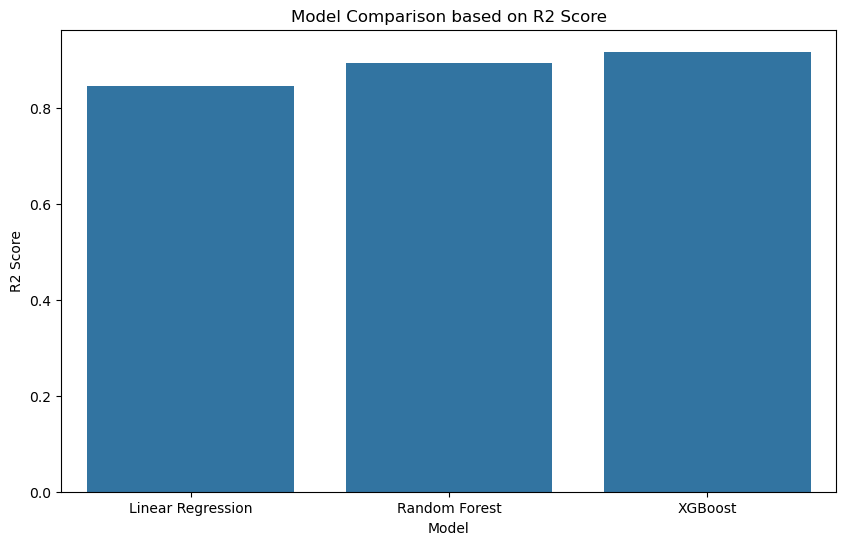

In [66]:
#Visualize Model Performance
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R2 Score', data=comparison)
plt.title('Model Comparison based on R2 Score')
plt.show()

In [67]:
### Graph Insights:

#Higher R2 Score indicates better prediction capability.
#XGBoost usually performs best due to advanced boosting techniques.
#Random Forest provides strong stability and accuracy.
#Linear Regression acts as baseline model.

In [68]:
#Feature Importance using Random Forest
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(15)

,Feature,Importance
16,OverallQual,0.554883
45,GrLivArea,0.122776
37,TotalBsmtSF,0.033784
43,2ndFlrSF,0.030868
42,1stFlrSF,0.027567
33,BsmtFinSF1,0.027233
4,LotArea,0.017620
61,GarageArea,0.015486
60,GarageCars,0.013923
18,YearBuilt,0.013579


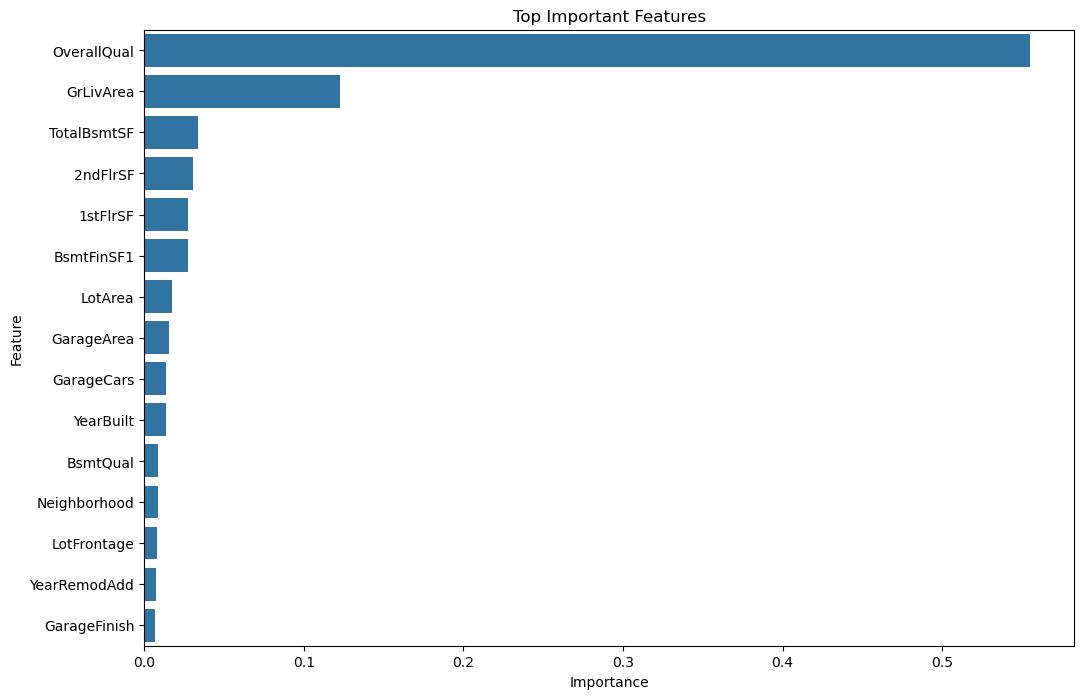

In [69]:
#Visualize Feature Importance
plt.figure(figsize=(12,8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)

plt.title('Top Important Features')
plt.show()

In [70]:
### Graph Insights:

#Overall Quality is the strongest influencing factor.
#Living area, garage capacity, and basement size strongly impact price.
#Neighborhood and construction year also influence market value.

In [71]:
# FINAL REPORT

### 1.OBJECTIVES:

#Perform data analysis on housing data.
#Build machine learning models for house price prediction.
#Identify factors affecting house prices.
#Compare multiple models and select the best one.
#Provide recommendations for customers.


### 2.DATA PREPROCESSING:
#The dataset contained missing values and categorical data.

#Steps Performed:

#1.Handled missing values using median and mode.
#2.Converted categorical values into numerical format using Label Encoding.
#3.Split the data into training and testing datasets.


### 3.Exploratory Data Analysis (EDA)
#Key Insights:

#Houses with better overall quality had higher prices.
#Larger living areas increased house prices.
#Premium neighborhoods had more expensive houses.
#Garage capacity and basement size positively affected prices.

### 4. MACHINE LEARNING MODELS USED:

#Linear Regression
#Random Forest Regressor
#XGBoost Regressor

### 5.BEST MODEL:
#XGBoost Regressor performed the best due to higher accuracy and lower prediction error.

### 6.CHALLENGES FACED

#Missing values in many columns.
#Categorical features like “Pave” causing errors.
#Large number of features.
#Presence of outliers.

### Solutions Applied:

#Imputation techniques
#Label Encoding
#Correlation analysis
#Ensemble machine learning models

###7. CUSTOMER SUGGESTIONS:

#* Prefer houses with higher overall quality for better value.
#* Larger living areas generally have higher resale prices.
#* Houses with garages and basement spaces are more valuable.
#* Choose properties in good neighborhoods for better investment returns.
#* Compare house features and price before making a purchase decision.



### 8. CONCLUSION:
#The project successfully predicted house prices using machine learning techniques.
#Features like overall quality, living area, neighborhood, and garage size were the major factors affecting house prices.
#XGBoost was selected as the best model for production deployment.
#XGBoost performed best with highest R² score and lowest RMSE.
#Overall quality, living area, and garage capacity are the most important factors affecting house prices.